# Explore here

Columnas disponibles en el dataset: Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
Etiquetas de calidad presentes en el dataset: [5 6 7 4 8 3]
Exactitud inicial con k=5: 0.5469
Matriz de confusión:
 [[ 0  0  0  1  0  0]
 [ 0  0  4  6  0  0]
 [ 0  2 88 40  0  0]
 [ 1  0 49 72 10  0]
 [ 0  0  7 20 15  0]
 [ 0  0  1  1  3  0]]
Reporte de clasificación:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.59      0.68      0.63       130
           6       0.51      0.55      0.53       132
           7       0.54      0.36      0.43        42
           8       0.00      0.00      0.00         5

    accuracy                           0.55       320
   macro avg       0.27      0.26 

/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


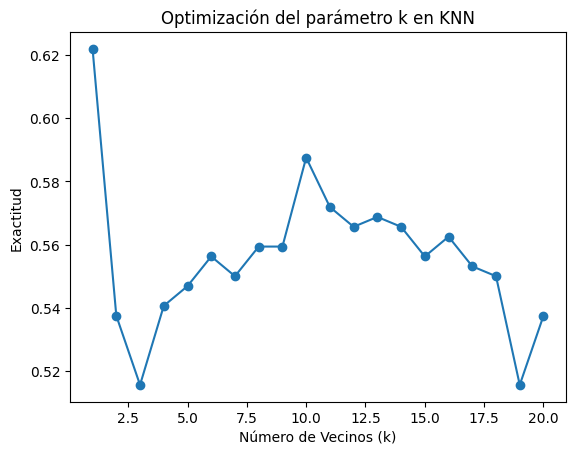

Este vino probablemente sea de Calidad media 🍷


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
# Your code here

# Importación de librerías necesarias
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import StandardScaler  
from sklearn.neighbors import KNeighborsClassifier  
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  

# Paso 1: Carga los datos desde la URL proporcionada
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/main/winequality-red.csv"
df = pd.read_csv(url, sep=";")

# Verificamos las columnas disponibles en el dataset
print("Columnas disponibles en el dataset:", df.columns)

# Paso 2: Separa las variables independientes (X) del objetivo (y)
target_column = "quality"
X = df.drop(columns=[target_column])  
y = df[target_column]  

# Verificar las etiquetas únicas
print("Etiquetas de calidad presentes en el dataset:", y.unique())

# Paso 3: Divide el conjunto de datos en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Paso 4: Escala los datos para mejorar el rendimiento del modelo KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)  

# Paso 5: Entrena el modelo KNN con un valor inicial de k
k_initial = 5
knn_model = KNeighborsClassifier(n_neighbors=k_initial)
knn_model.fit(X_train_scaled, y_train)

# Paso 6: Evalúa el rendimiento del modelo inicial
y_pred = knn_model.predict(X_test_scaled)
print(f"Exactitud inicial con k={k_initial}: {accuracy_score(y_test, y_pred):.4f}")
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("Reporte de clasificación:\n", classification_report(y_test, y_pred))

# Paso 7: Optimización del valor de k probando diferentes opciones
k_values = range(1, 21)
accuracy_results = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    accuracy_results.append(accuracy_score(y_test, y_pred_temp))

# Paso 8: Grafica accuracy vs k para encontrar el mejor valor
plt.plot(k_values, accuracy_results, marker="o")
plt.xlabel("Número de Vecinos (k)")
plt.ylabel("Exactitud")
plt.title("Optimización del parámetro k en KNN")
plt.show()

# Paso 9: Crea una función que reciba valores numéricos y prediga la calidad del vino
def predict_wine_quality(features):
    features_scaled = scaler.transform([features])  
    prediction = knn_model.predict(features_scaled)[0]  
    
    # Diccionario actualizado con todas las etiquetas posibles
    quality_labels = {
        3: "Muy baja calidad 🍷", 4: "Baja calidad 🍷", 5: "Calidad media 🍷",
        6: "Buena calidad 🍷", 7: "Alta calidad 🍷", 8: "Excelente calidad 🍷"
    }
    
    return f"Este vino probablemente sea de {quality_labels.get(prediction, 'calidad desconocida')}"

# Ejemplo de uso de la función de predicción
sample_wine = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
print(predict_wine_quality(sample_wine))
